# 📌 Задание №1: Обработка пропущенных значений

Задание:

Используя библиотеку Pandas, выполните следующие шаги для обработки набора данных клиентов:

1. **Генерация исходных данных**: создайте фрейм данных `df`, содержащий следующие столбцы:
   - ID — уникальный идентификатор клиента,
   - gender — пол клиента («Male», «Female»), задан случайным образом,
   - age — возраст клиента, с вероятностью пропуска значения 10%,
   - income — доход клиента, равномерно распределённый между 20 тыс. и 100 тыс.,
   - avg_check — средний чек покупки клиента, нормальным распределением вокруг среднего значения 5000 рублей и стандартным отклонением 1000 рублей.
   
2. **Анализ пропущенных значений**:
   - Определите процент пропущенных значений по каждому признаку (`isnull()`).

3. **Обработка пропущенных значений**:
   - Пропущенные значения в колонке `age` заполните медианой возрастов.
   - Строки с отсутствующими значениями доходов удалите.

4. **Проверка результата**: выведите первые пять строк обработанного DataFrame.

Реализуйте этот процесс в Python-коде.

Задание:

In [22]:
import pandas as pd
import numpy as np
import sns

# Генерация синтетических данных клиентов

n = 100
rng = np.random.default_rng()
missing_rate = rng.uniform(0, 1)
incomes = np.random.uniform(20_000, 100_000, size=n)
mask = np.random.random(n) < missing_rate
incomes[mask] = np.nan

data = {
    'ID': range(1, 101),  # Идентификаторы пользователей
    'gender': np.random.choice(['Male', 'Female'], size=100),  # Пол выбран случайно среди Male/Female
    'age': np.random.choice([None, *range(18, 60)], size=100, p=[0.1] + [(0.9 / 42)] * 42),  # Возраст
   # 'income': np.random.uniform(20_000, 100_000, size=100),  # Доход
    'income': incomes,
    'avg_check': np.random.normal(loc=5000, scale=1000, size=100)  # Средний чек
}

df = pd.DataFrame(data)

# Процент пропущенных значений по каждому признаку
missing_df = pd.DataFrame({
    'Признак': df.columns,
    'Процент пропусков': df.isnull().mean() * 100
})
print(missing_df)

# Заполняем пропуски медианы возраста
median_age = df['age'].median()
print(f'\nСредний возраст {median_age}\n')

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(median_age)

# Убираем строки с пропущенными значениями дохода
df.dropna(subset=['income'], inplace=True)
# Проверяем результат
print(f'{df.head()}\n')

df.info()

             Признак  Процент пропусков
ID                ID                0.0
gender        gender                0.0
age              age                7.0
income        income               38.0
avg_check  avg_check                0.0

Средний возраст 40.0

   ID  gender   age        income    avg_check
1   2  Female  31.0  95691.674188  5944.420772
3   4  Female  56.0  73928.995057  6363.328434
4   5    Male  59.0  37546.400220  5614.471238
6   7  Female  57.0  91191.886519  5738.269713
8   9    Male  33.0  70774.309500  4881.039898

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 1 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         62 non-null     int64  
 1   gender     62 non-null     object 
 2   age        62 non-null     float64
 3   income     62 non-null     float64
 4   avg_check  62 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 2.9+ KB


Решение:

In [12]:
import pandas as pd
import numpy as np



# Генерация синтетических данных клиентов
data = {
    'ID': range(1, 101),  # Идентификаторы пользователей
    'gender': np.random.choice(['Male', 'Female'], size=100),  # Пол выбран случайно среди Male/Female
    'age': np.random.choice([None, *range(18, 60)], size=100, p=[0.1] + [(0.9 / 42)] * 42),  # Возраст
    'income': np.random.uniform(20_000, 100_000, size=100),  # Доход
    'avg_check': np.random.normal(loc=5000, scale=1000, size=100)  # Средний чек
}

df = pd.DataFrame(data)

# Процент пропущенных значений по каждому признаку
missing_values_percent = df.isnull().mean() * 100
print(missing_values_percent)

# Заполняем пропуски медианы возраста
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# Убираем строки с пропущенными значениями дохода
df.dropna(subset=['income'], inplace=True)

# Проверяем результат
print(df.head())

ID           0.0
gender       0.0
age          8.0
income       0.0
avg_check    0.0
dtype: float64
   ID  gender   age        income    avg_check
0   1    Male  58.0  98949.663882  3719.077233
1   2  Female  27.0  72678.806161  3145.437503
2   3  Female  19.0  44544.888409  4281.129899
3   4    Male  31.0  79430.858173  4326.351085
4   5  Female  39.5  89302.141958  4678.385396


d:\Temp\ipykernel_5460\1817627437.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].fillna(median_age)


# 📌 Задание №2: Работа с выбросами методом IQR

Задание:

Задача:

Напишите программу на Python, которая создаёт синтетический набор данных о продуктах с ценами и очищает его от выбросов с помощью метода межквартильного размаха (Interquartile Range, IQR). Программа должна выводить первые несколько строк очищенной выборки.
Шаги программы:

- Сгенерируйте синтетические данные продуктов, используя две категории товаров:
  - Большая группа товаров со средней ценой около 100 рублей и небольшим разбросом (стандартное отклонение ~20 руб.).
  - Небольшое количество товаров с высокой стоимостью (~500–1000 руб.) для симуляции выбросов.
- Рассчитайте границы нормальных значений цен, применяя правило IQR (нижняя граница: Q1 − 1.5 × IQR, верхняя граница: Q3 + 1.5 × IQR).
- Отфильтруйте товары, цены которых выходят за рамки нормального диапазона, определённого с помощью IQR.
- Выведите первую часть очищенного набора данных.



In [23]:
import pandas as pd
import numpy as np

# Генерация синтетических данных о товарах
prices = np.concatenate([
    np.random.normal(loc=100, scale=20, size=90),  # Основная масса товаров
    np.random.uniform(low=500, high=1000, size=10)  # Несколько дорогих товаров-выбросов
])

data = {'product_id': range(1, 101), 'price': prices}
df = pd.DataFrame(data)

# Ваш код ниже

print(df)

    product_id       price
0            1  113.859197
1            2  127.568887
2            3   77.369109
3            4   80.606217
4            5  110.535901
..         ...         ...
95          96  879.721741
96          97  712.369049
97          98  762.391005
98          99  793.051560
99         100  759.876408

[100 rows x 2 columns]


Исходный датасет (первые 10 строк):
   product_id   price
0           1   89.80
1           2  112.12
2           3  610.38
3           4   98.75
4           5  123.19
5           6   87.92
6           7  116.41
7           8   74.10
8           9   86.96
9          10   75.99

Всего записей: 1000

Q1 = 88.52
Q3 = 119.08
IQR = 30.56
Нижняя граница = 42.67
Верхняя граница = 164.93

Очищенный датасет (первые 10 строк):
    product_id   price
0            1   89.80
1            2  112.12
3            4   98.75
4            5  123.19
5            6   87.92
6            7  116.41
7            8   74.10
8            9   86.96
9           10   75.99
10          11   84.06

Осталось записей: 898
Удалено выбросов: 102


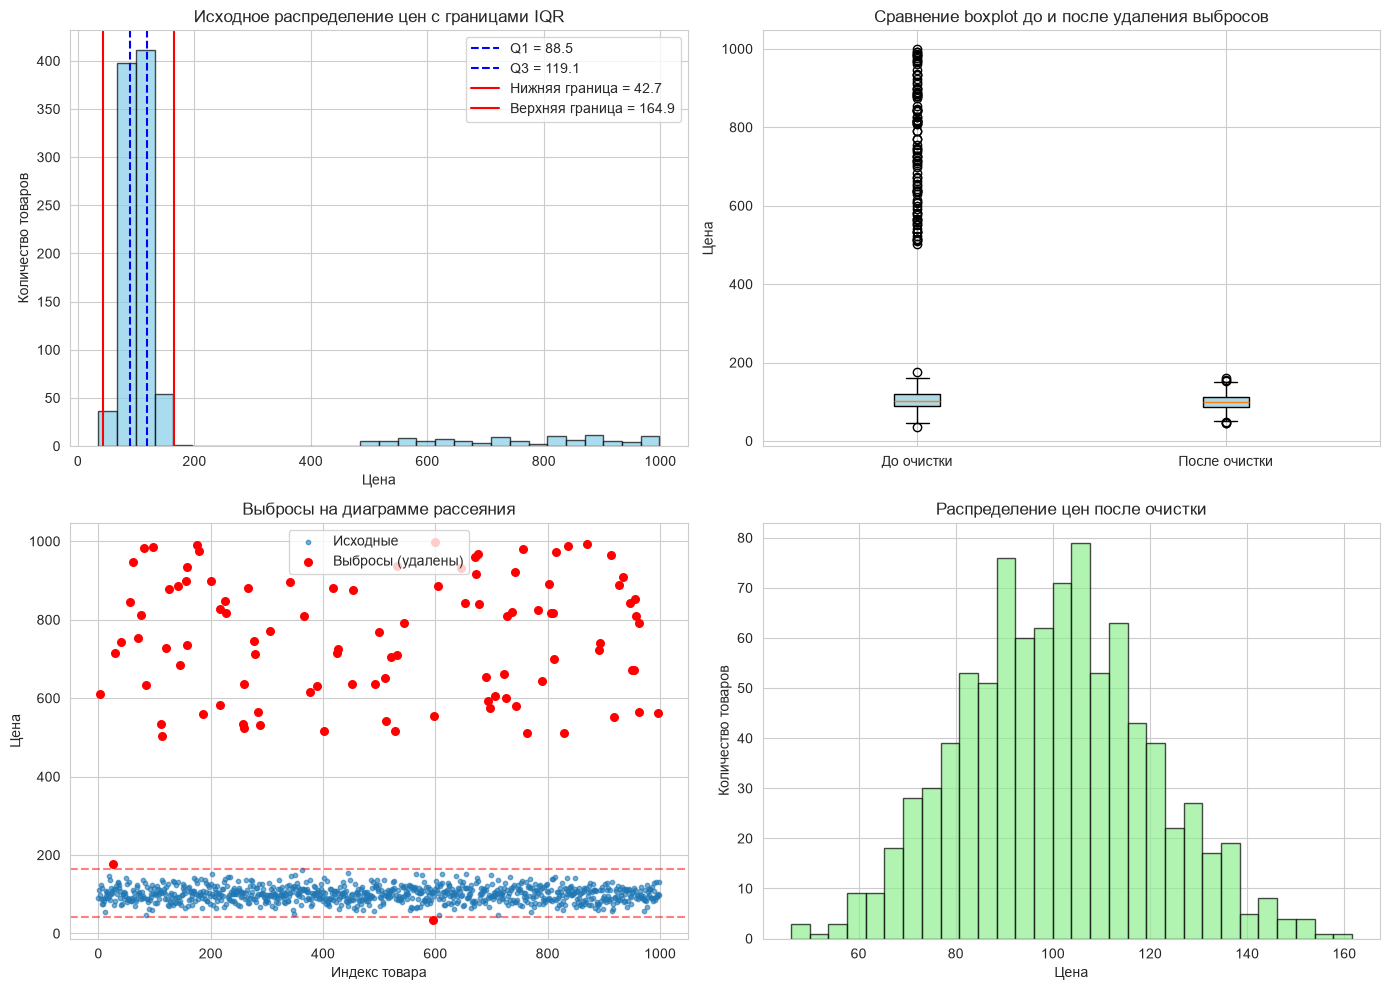

In [32]:


import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

# Фиксируем seed для воспроизводимости
np.random.seed(42)

# --- 1. Генерация данных ---
n_usual = 900        # товары со средней ценой ~100 руб.
n_expensive = 100     # дорогие товары (симуляция выбросов)

# Обычные цены (нормальное распределение)
prices_usual = np.random.normal(loc=100, scale=20, size=n_usual)
prices_usual = np.round(np.maximum(prices_usual, 1), 2)   # цена не ниже 1

# Дорогие цены (равномерное распределение)
prices_expensive = np.random.uniform(500, 1000, size=n_expensive)
prices_expensive = np.round(prices_expensive, 2)

# Объединяем и перемешиваем
prices = np.concatenate([prices_usual, prices_expensive])
np.random.shuffle(prices)

df = pd.DataFrame({
    'product_id': range(1, len(prices) + 1),
    'price': prices
})

print("Исходный датасет (первые 10 строк):")
print(df.head(10))
print(f"\nВсего записей: {len(df)}")

# --- 2. Расчёт IQR ---
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Нижняя граница = {lower_bound:.2f}")
print(f"Верхняя граница = {upper_bound:.2f}")

# --- 3. Очистка от выбросов ---
df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# --- 4. Вывод первых строк очищенной выборки ---
print("\nОчищенный датасет (первые 10 строк):")
print(df_cleaned.head(10))
print(f"\nОсталось записей: {len(df_cleaned)}")
print(f"Удалено выбросов: {len(df) - len(df_cleaned)}")

sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# ---- 1. Гистограмма исходных цен с границами IQR ----
plt.subplot(2, 2, 1)
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(Q1, color='blue', linestyle='--', label=f'Q1 = {Q1:.1f}')
plt.axvline(Q3, color='blue', linestyle='--', label=f'Q3 = {Q3:.1f}')
plt.axvline(lower_bound, color='red', linestyle='-', label=f'Нижняя граница = {lower_bound:.1f}')
plt.axvline(upper_bound, color='red', linestyle='-', label=f'Верхняя граница = {upper_bound:.1f}')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.title('Исходное распределение цен с границами IQR')
plt.legend()

# ---- 2. Boxplot до и после очистки ----


plt.subplot(2, 2, 2)
data_to_plot = [df['price'], df_cleaned['price']]
plt.boxplot(data_to_plot, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.xticks([1, 2], ['До очистки', 'После очистки'])   # ← задаём подписи здесь
plt.title('Сравнение boxplot до и после удаления выбросов')
plt.ylabel('Цена')

# ---- 3. Диаграмма рассеяния (индекс vs цена) до очистки ----
plt.subplot(2, 2, 3)
plt.scatter(df.index, df['price'], alpha=0.6, s=10, label='Исходные')
# Отметим выбросы (те, что будут удалены)
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
plt.scatter(outliers.index, outliers['price'], color='red', s=30, label='Выбросы (удалены)')
plt.axhline(lower_bound, color='red', linestyle='--', alpha=0.5)
plt.axhline(upper_bound, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Индекс товара')
plt.ylabel('Цена')
plt.title('Выбросы на диаграмме рассеяния')
plt.legend()

# ---- 4. Гистограмма очищенных данных ----
plt.subplot(2, 2, 4)
plt.hist(df_cleaned['price'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.title('Распределение цен после очистки')

plt.tight_layout()
plt.show()

Решение:

In [ ]:
import pandas as pd
import numpy as np

# Генерация синтетических данных о товарах
prices = np.concatenate([
    np.random.normal(loc=100, scale=20, size=90),  # Основная масса товаров
    np.random.uniform(low=500, high=1000, size=10)  # Несколько дорогих товаров-выбросов
])

data = {'product_id': range(1, 101), 'price': prices}
df = pd.DataFrame(data)

# Расчёт квартилей и IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Определение границ допустимых значений
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Удаление строк с выбросами
filtered_df = df[(df['price'] > lower_bound) & (df['price'] < upper_bound)]

# Просмотр очищенного датасета
print(filtered_df.head())

   product_id       price
0           1  121.018832
1           2   90.857537
2           3  112.945264
3           4   89.638171
4           5  113.305853


# 📌 Задание №3: Объединение и удаление дубликатов

Задание:

Объедините две таблицы сотрудников, содержащие ФИО, должность и электронную почту, по общему ключу (ФИО и должность), исключив дублирование записей. Покажите первые строки полученного фрейма данных с полными сведениями о каждом сотруднике.

Задание:

In [ ]:
import pandas as pd
import random

# Генерация синтетических данных о сотрудниках
names = ["Иванов", "Петров", "Смирнов"] * 3
positions = ["Менеджер", "Разработчик", "Дизайнер"] * 3
email_domains = ["@example.com", "@company.ru"]

# Теперь имя тоже повторяется три раза, чтобы соответствовать длине остальных столбцов
first_names = ["Иван", "Андрей", "Алексей"] * 3

# Создаем dataframe сотрудников
employees = pd.DataFrame({
  # Ваш код здесь...
})

# Генерируем email адреса
emails = pd.DataFrame({
  # Ваш код здесь...
})

# Объединение таблиц по ФИО
merged_df = # Ваш код здесь...

# Удаление повторяющихся строк
deduplicated_df = # Ваш код здесь...

# Показываем первые строки результата
print(deduplicated_df.head())

Решение:

In [ ]:
import pandas as pd
import random

# Генерация синтетических данных о сотрудниках
names = ["Иванов", "Петров", "Смирнов"] * 3
positions = ["Менеджер", "Разработчик", "Дизайнер"] * 3
email_domains = ["@example.com", "@company.ru"]

# Теперь имя тоже повторяется три раза, чтобы соответствовать длине остальных столбцов
first_names = ["Иван", "Андрей", "Алексей"] * 3

# Создаем dataframe сотрудников
employees = pd.DataFrame({
    'first_name': first_names,           # имена
    'last_name': names[:len(first_names)],  # фамилии
    'position': positions                # должности
})

# Генерируем email адреса
emails = pd.DataFrame({
    'first_name': first_names,            # имена
    'last_name': names[:len(first_names)],  # фамилии
    'email': [f"{fn.lower()}.{ln.lower()}{random.choice(email_domains)}"
               for fn, ln in zip(first_names, names)]  # почта
})

# Объединение таблиц по ФИО
merged_df = employees.merge(emails, on=['first_name', 'last_name'])

# Удаление повторяющихся строк
deduplicated_df = merged_df.drop_duplicates()

# Показываем первые строки результата
print(deduplicated_df.head())

  first_name last_name     position                       email
0       Иван    Иванов     Менеджер      иван.иванов@company.ru
3     Андрей    Петров  Разработчик    андрей.петров@company.ru
4     Андрей    Петров  Разработчик   андрей.петров@example.com
6    Алексей   Смирнов     Дизайнер  алексей.смирнов@company.ru


# 📌 Задание №4: Обнаружение и исправление аномалий с помощью Z-Score

Задание:
Очистите набор медицинских данных, содержащих показатели артериального давления пациентов, от аномальных выбросов методом Z-Score. Данные содержат искусственно внесённые экстремально высокие значения систолического и диастолического давления. Необходимо рассчитать Z-Score для обоих показателей, заменить выбросы средним значением соответствующей колонки и показать первые строки очищенного датасета.

Задание:

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Генерация синтетических данных медицинского обследования
sys_bp = np.concatenate([
  # Ваш код здесь...
])

dia_bp = np.concatenate([
  # Ваш код здесь...
])

data = {
    'patient_id': range(1, 101),
    'systolic_bp': sys_bp,
    'diastolic_bp': dia_bp
}

df = pd.DataFrame(data)

# Ваш код здесь...

ИСХОДНЫЕ ДАННЫЕ
   patient_id  systolic_bp  diastolic_bp
0           1   124.967142     68.291880
1           2   118.617357     82.368962
2           3   126.476885     82.088442
3           4   135.230299     80.040908
4           5   117.658466     78.123303
5           6   117.658630     68.677034
6           7   135.792128     76.634837
7           8   127.674347     77.258284
8           9   115.305256     73.581782
9          10   125.425600     78.709714

Всего строк: 100

Базовая статистика до очистки:
       systolic_bp  diastolic_bp
count   100.000000    100.000000
mean    126.375116     85.237824
std      33.765917     23.325554
min      93.802549     64.649830
25%     114.281247     73.911076
50%     119.460819     81.436847
75%     126.703830     85.787869
max     300.000000    200.000000


d:\Temp\ipykernel_5460\2695063220.py:101: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box2 = axes[1, 1].boxplot(df['diastolic_bp'], vert=True, patch_artist=True,


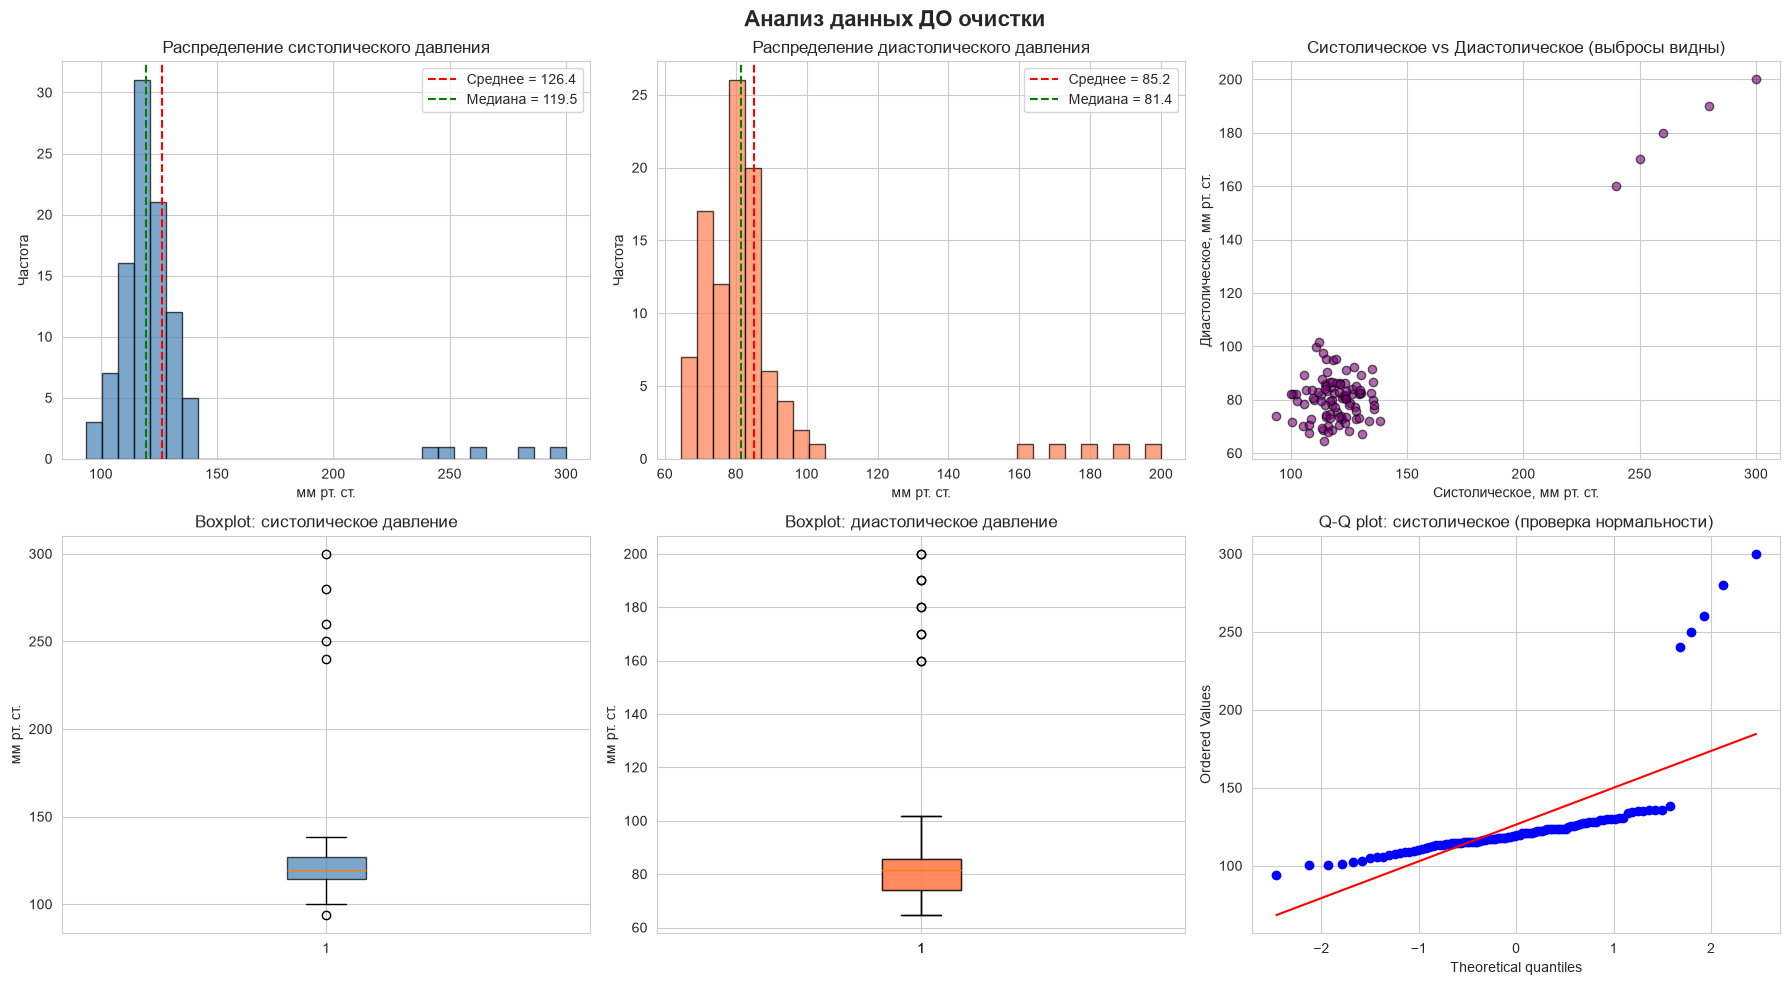


Z-SCORE
   patient_id  systolic_bp  z_systolic  diastolic_bp  z_diastolic
0           1   124.967142    0.041908     68.291880     0.730157
1           2   118.617357    0.230909     82.368962     0.123612
2           3   126.476885    0.003029     82.088442     0.135699
3           4   135.230299    0.263573     80.040908     0.223922
4           5   117.658466    0.259450     78.123303     0.306546
5           6   117.658630    0.259445     68.677034     0.713562
6           7   135.792128    0.280296     76.634837     0.370680
7           8   127.674347    0.038671     77.258284     0.343818
8           9   115.305256    0.329493     73.581782     0.502229
9          10   125.425600    0.028262     78.709714     0.281279

Выбросов в систолическом: 5
Выбросов в диастолическом: 5


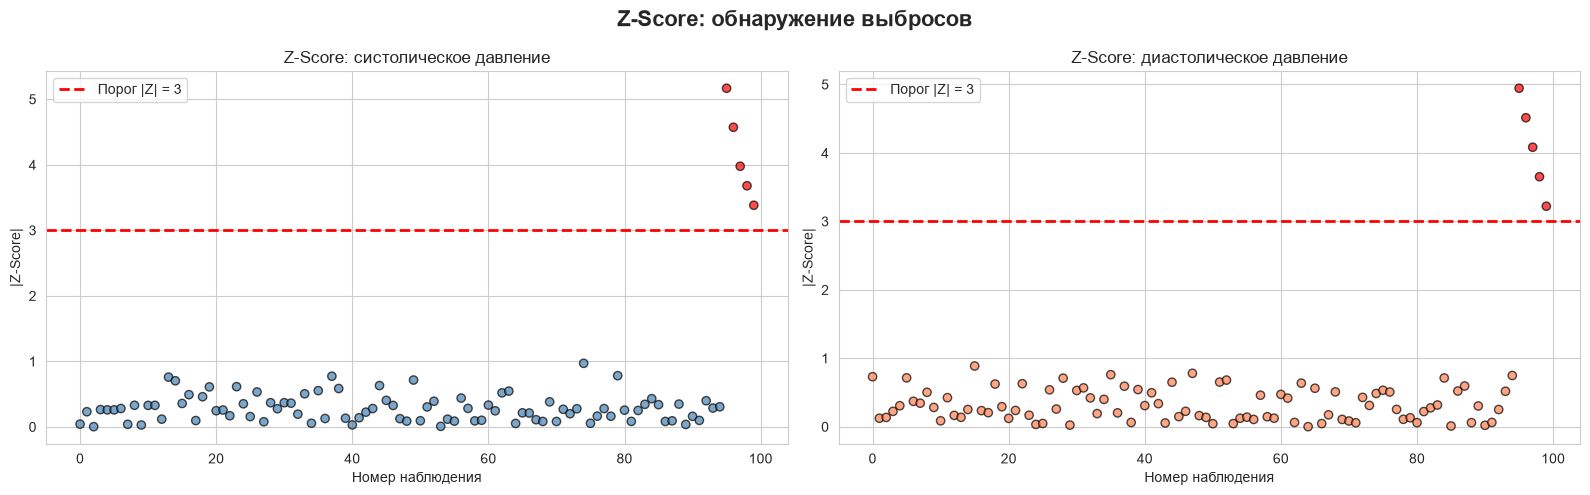


СТАТИСТИКА ПО ЧИСТЫМ ДАННЫМ
Среднее систолическое (без выбросов): 119.03
Медиана систолического (без выбросов): 118.62
Среднее диастолическое (без выбросов): 80.25
Медиана диастолического (без выбросов): 80.55


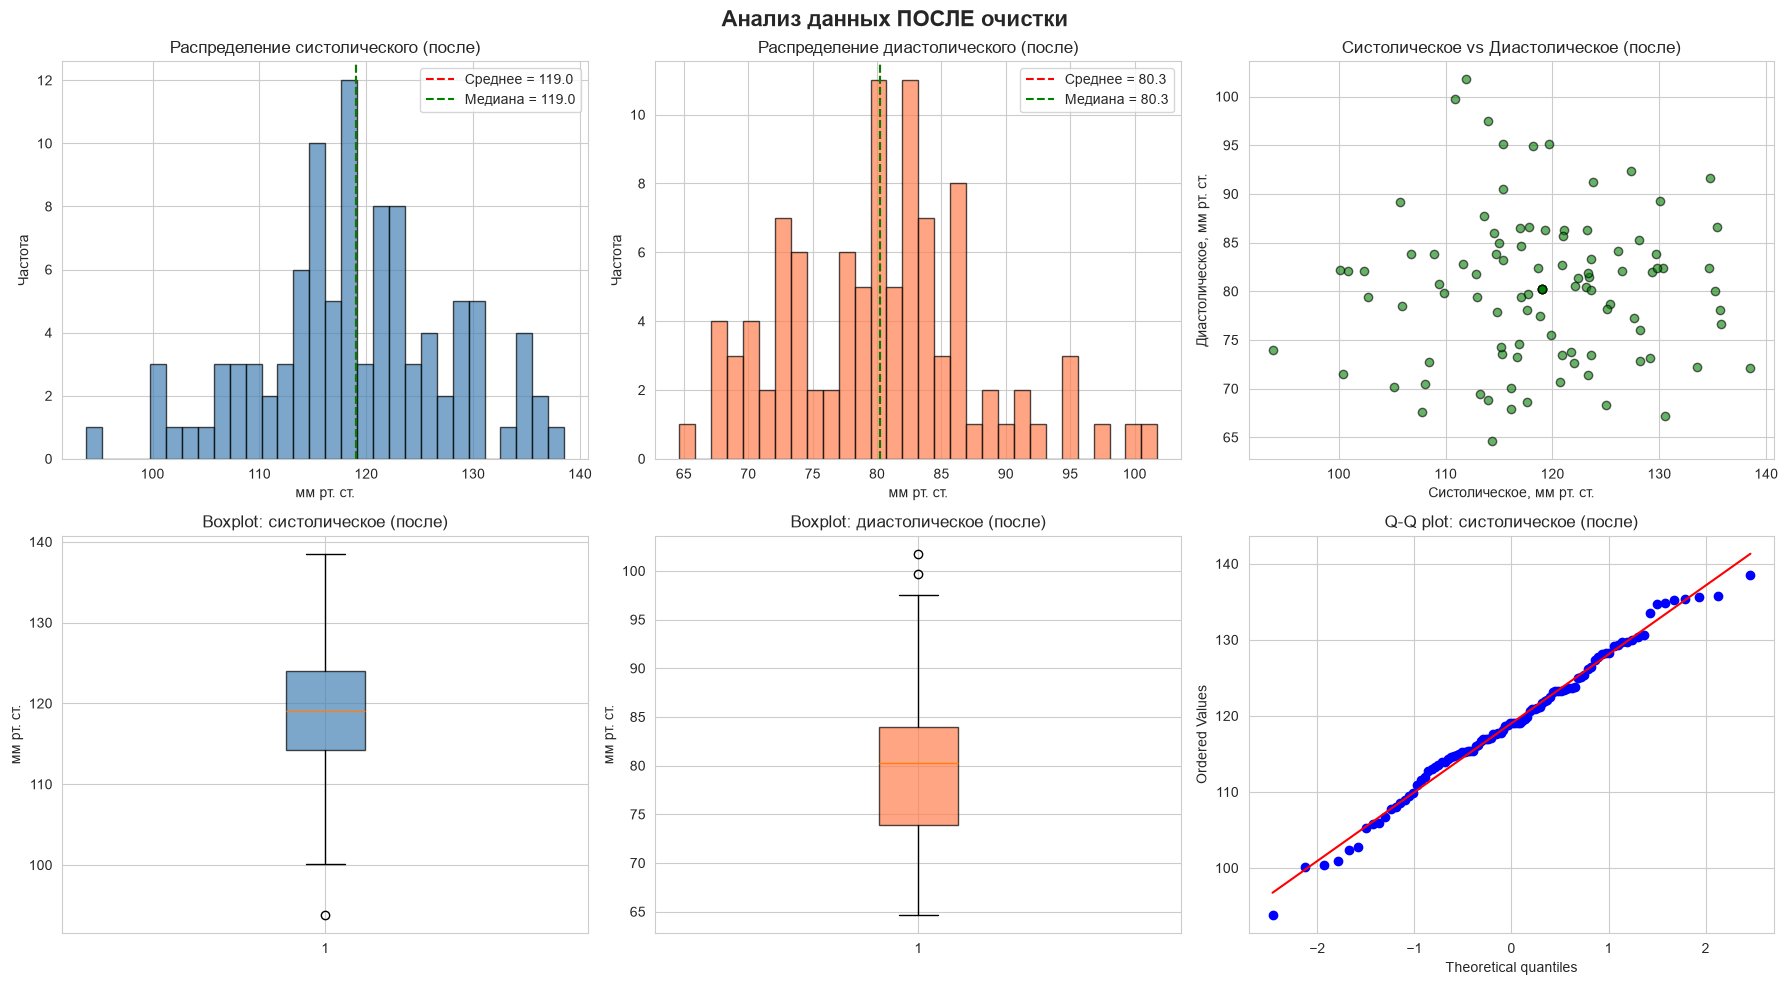

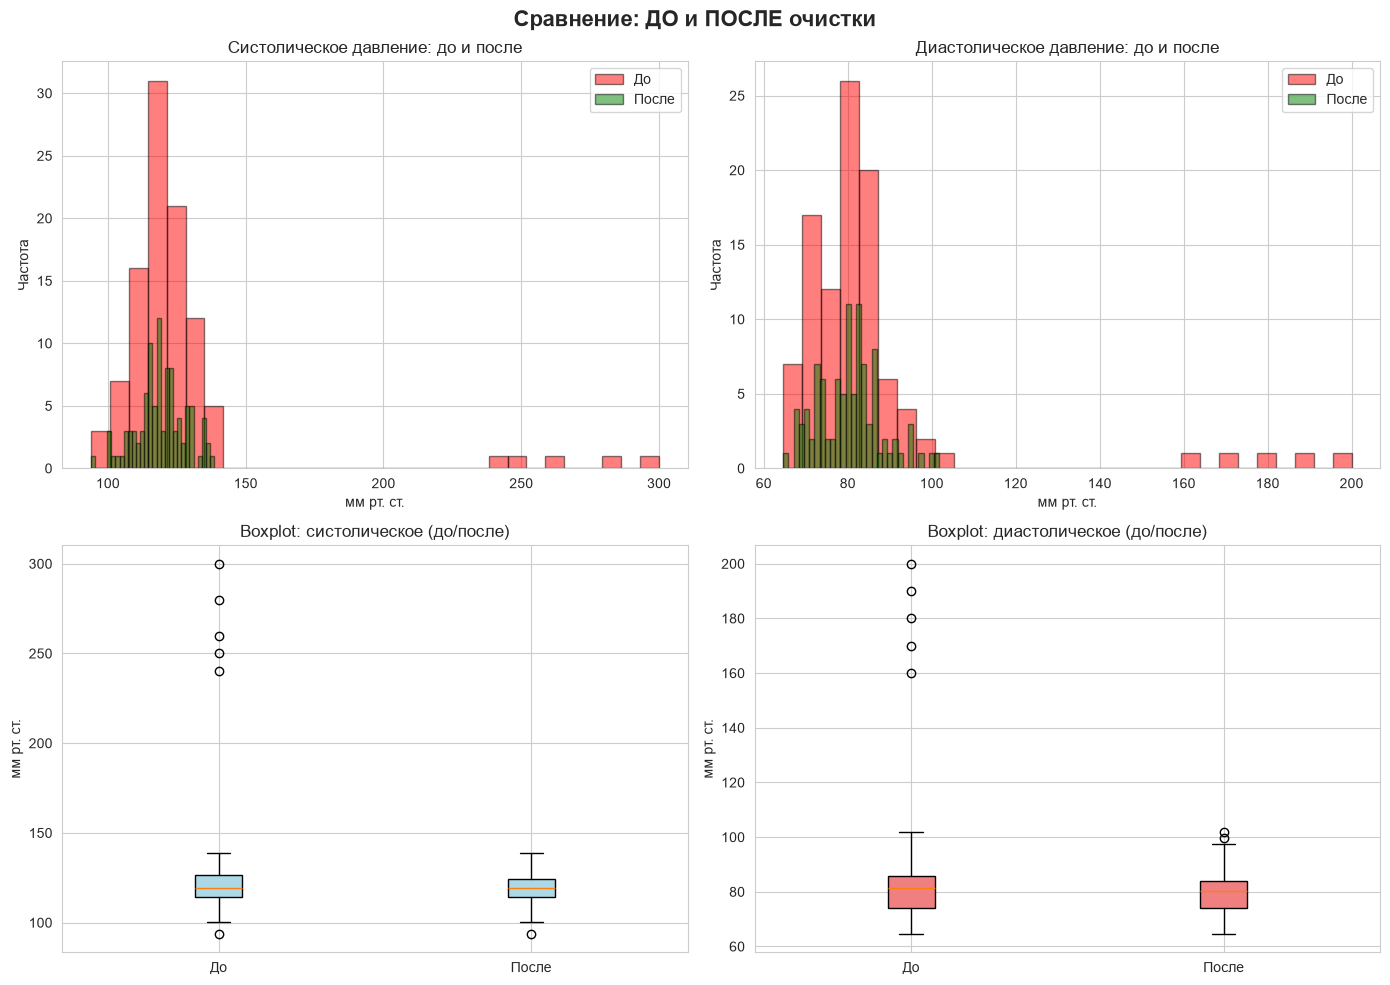


ИТОГОВЫЙ ОЧИЩЕННЫЙ ДАТАСЕТ (первые 10 строк)
   patient_id  systolic_bp  diastolic_bp
0           1   124.967142     68.291880
1           2   118.617357     82.368962
2           3   126.476885     82.088442
3           4   135.230299     80.040908
4           5   117.658466     78.123303
5           6   117.658630     68.677034
6           7   135.792128     76.634837
7           8   127.674347     77.258284
8           9   115.305256     73.581782
9          10   125.425600     78.709714

СТАТИСТИКА ДО И ПОСЛЕ
    Показатель  Сис. ДО  Сис. ПОСЛЕ  Диас. ДО  Диас. ПОСЛЕ
       Среднее   126.38      119.03     85.24        80.25
       Медиана   119.46      119.03     81.44        80.25
Ст. отклонение    33.77        8.96     23.33         7.52
      Максимум   300.00      138.52    200.00       101.76
       Минимум    93.80       93.80     64.65        64.65

✅ Очищенные данные сохранены в 'cleaned_medical_data.csv'


In [36]:
# ============================================================
# ИМПОРТ БИБЛИОТЕК
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Воспроизводимость
np.random.seed(42)


# ============================================================
# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# ============================================================
# Нормальные показатели: систолическое ~120±10, диастолическое ~80±8
# Плюс 5 экстремальных выбросов в каждом показателе

sys_bp = np.concatenate([
    np.random.normal(loc=120, scale=10, size=95),   # 95 нормальных значений
    np.array([300, 280, 260, 250, 240])             # 5 выбросов
])

dia_bp = np.concatenate([
    np.random.normal(loc=80, scale=8, size=95),     # 95 нормальных значений
    np.array([200, 190, 180, 170, 160])             # 5 выбросов
])

df = pd.DataFrame({
    'patient_id': range(1, 101),
    'systolic_bp': sys_bp,
    'diastolic_bp': dia_bp
})

# Сохраняем копию исходных данных для сравнения
df_original = df.copy()

print("=" * 60)
print("ИСХОДНЫЕ ДАННЫЕ")
print("=" * 60)
print(df.head(10))
print(f"\nВсего строк: {len(df)}")
print(f"\nБазовая статистика до очистки:")
print(df[['systolic_bp', 'diastolic_bp']].describe())


# ============================================================
# 2. ВИЗУАЛИЗАЦИЯ ДО ОЧИСТКИ
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ данных ДО очистки', fontsize=16, fontweight='bold')

# --- 2.1 Гистограмма систолического давления ---
axes[0, 0].hist(df['systolic_bp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['systolic_bp'].mean(), color='red', linestyle='--',
                   label=f'Среднее = {df["systolic_bp"].mean():.1f}')
axes[0, 0].axvline(df['systolic_bp'].median(), color='green', linestyle='--',
                   label=f'Медиана = {df["systolic_bp"].median():.1f}')
axes[0, 0].set_title('Распределение систолического давления')
axes[0, 0].set_xlabel('мм рт. ст.')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# --- 2.2 Гистограмма диастолического давления ---
axes[0, 1].hist(df['diastolic_bp'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['diastolic_bp'].mean(), color='red', linestyle='--',
                   label=f'Среднее = {df["diastolic_bp"].mean():.1f}')
axes[0, 1].axvline(df['diastolic_bp'].median(), color='green', linestyle='--',
                   label=f'Медиана = {df["diastolic_bp"].median():.1f}')
axes[0, 1].set_title('Распределение диастолического давления')
axes[0, 1].set_xlabel('мм рт. ст.')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()

# --- 2.3 Scatter plot: систолическое vs диастолическое ---
axes[0, 2].scatter(df['systolic_bp'], df['diastolic_bp'],
                   c='purple', alpha=0.6, edgecolors='black')
axes[0, 2].set_title('Систолическое vs Диастолическое (выбросы видны)')
axes[0, 2].set_xlabel('Систолическое, мм рт. ст.')
axes[0, 2].set_ylabel('Диастолическое, мм рт. ст.')

# --- 2.4 Boxplot систолического ---
axes[1, 0].boxplot(df['systolic_bp'], patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1, 0].set_title('Boxplot: систолическое давление')
axes[1, 0].set_ylabel('мм рт. ст.')

# --- 2.5 Boxplot диастолического ---
axes[1, 1].boxplot(df['diastolic_bp'], patch_artist=True,
                   boxprops=dict(facecolor='coral', alpha=0.7))
axes[1, 1].set_title('Boxplot: диастолическое давление')
axes[1, 1].set_ylabel('мм рт. ст.')

# --- 2.5 Boxplot диастолического ---
box2 = axes[1, 1].boxplot(df['diastolic_bp'], vert=True, patch_artist=True,
                          boxprops=dict(facecolor='coral', alpha=0.7))
axes[1, 1].set_title('Boxplot: диастолическое давление')
axes[1, 1].set_ylabel('мм рт. ст.')

# --- 2.6 Q-Q plot (проверка нормальности) ---
stats.probplot(df['systolic_bp'], dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q plot: систолическое (проверка нормальности)')

plt.tight_layout()
plt.savefig('before_cleaning.png', dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
# 3. РАСЧЁТ Z-SCORE
# ============================================================
# Z-Score = (x - mean) / std
# |Z| > 3 — выброс (правило трёх сигм)

df['z_systolic'] = np.abs(stats.zscore(df['systolic_bp']))
df['z_diastolic'] = np.abs(stats.zscore(df['diastolic_bp']))

print("\n" + "=" * 60)
print("Z-SCORE")
print("=" * 60)
print(df[['patient_id', 'systolic_bp', 'z_systolic',
          'diastolic_bp', 'z_diastolic']].head(10))

# Подсчёт выбросов
n_outliers_sys = (df['z_systolic'] > 3).sum()
n_outliers_dia = (df['z_diastolic'] > 3).sum()

print(f"\nВыбросов в систолическом: {n_outliers_sys}")
print(f"Выбросов в диастолическом: {n_outliers_dia}")


# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ Z-SCORE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Z-Score: обнаружение выбросов', fontsize=16, fontweight='bold')

# --- 4.1 Z-Score систолического ---
axes[0].scatter(range(len(df)), df['z_systolic'],
                c=['red' if z > 3 else 'steelblue' for z in df['z_systolic']],
                alpha=0.7, edgecolors='black')
axes[0].axhline(y=3, color='red', linestyle='--', linewidth=2, label='Порог |Z| = 3')
axes[0].set_title('Z-Score: систолическое давление')
axes[0].set_xlabel('Номер наблюдения')
axes[0].set_ylabel('|Z-Score|')
axes[0].legend()

# --- 4.2 Z-Score диастолического ---
axes[1].scatter(range(len(df)), df['z_diastolic'],
                c=['red' if z > 3 else 'coral' for z in df['z_diastolic']],
                alpha=0.7, edgecolors='black')
axes[1].axhline(y=3, color='red', linestyle='--', linewidth=2, label='Порог |Z| = 3')
axes[1].set_title('Z-Score: диастолическое давление')
axes[1].set_xlabel('Номер наблюдения')
axes[1].set_ylabel('|Z-Score|')
axes[1].legend()

plt.tight_layout()
plt.savefig('zscore_outliers.png', dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
# 5. ЗАМЕНА ВЫБРОСОВ СРЕДНИМ (без учёта выбросов)
# ============================================================
# ВАЖНО: среднее считаем только по «чистым» значениям (|Z| <= 3)

mean_sys_clean = df.loc[df['z_systolic'] <= 3, 'systolic_bp'].mean()
mean_dia_clean = df.loc[df['z_diastolic'] <= 3, 'diastolic_bp'].mean()

median_sys_clean = df.loc[df['z_systolic'] <= 3, 'systolic_bp'].median()
median_dia_clean = df.loc[df['z_diastolic'] <= 3, 'diastolic_bp'].median()

print("\n" + "=" * 60)
print("СТАТИСТИКА ПО ЧИСТЫМ ДАННЫМ")
print("=" * 60)
print(f"Среднее систолическое (без выбросов): {mean_sys_clean:.2f}")
print(f"Медиана систолического (без выбросов): {median_sys_clean:.2f}")
print(f"Среднее диастолическое (без выбросов): {mean_dia_clean:.2f}")
print(f"Медиана диастолического (без выбросов): {median_dia_clean:.2f}")

# Замена выбросов средним
df.loc[df['z_systolic'] > 3, 'systolic_bp'] = mean_sys_clean
df.loc[df['z_diastolic'] > 3, 'diastolic_bp'] = mean_dia_clean

# Удаляем вспомогательные колонки
df.drop(columns=['z_systolic', 'z_diastolic'], inplace=True)


# ============================================================
# 6. ВИЗУАЛИЗАЦИЯ ПОСЛЕ ОЧИСТКИ
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ данных ПОСЛЕ очистки', fontsize=16, fontweight='bold')

# --- 6.1 Гистограмма систолического ---
axes[0, 0].hist(df['systolic_bp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['systolic_bp'].mean(), color='red', linestyle='--',
                   label=f'Среднее = {df["systolic_bp"].mean():.1f}')
axes[0, 0].axvline(df['systolic_bp'].median(), color='green', linestyle='--',
                   label=f'Медиана = {df["systolic_bp"].median():.1f}')
axes[0, 0].set_title('Распределение систолического (после)')
axes[0, 0].set_xlabel('мм рт. ст.')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# --- 6.2 Гистограмма диастолического ---
axes[0, 1].hist(df['diastolic_bp'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['diastolic_bp'].mean(), color='red', linestyle='--',
                   label=f'Среднее = {df["diastolic_bp"].mean():.1f}')
axes[0, 1].axvline(df['diastolic_bp'].median(), color='green', linestyle='--',
                   label=f'Медиана = {df["diastolic_bp"].median():.1f}')
axes[0, 1].set_title('Распределение диастолического (после)')
axes[0, 1].set_xlabel('мм рт. ст.')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()

# --- 6.3 Scatter plot после очистки ---
axes[0, 2].scatter(df['systolic_bp'], df['diastolic_bp'],
                   c='green', alpha=0.6, edgecolors='black')
axes[0, 2].set_title('Систолическое vs Диастолическое (после)')
axes[0, 2].set_xlabel('Систолическое, мм рт. ст.')
axes[0, 2].set_ylabel('Диастолическое, мм рт. ст.')

# --- 6.4 Boxplot систолического ---
axes[1, 0].boxplot(df['systolic_bp'],  patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1, 0].set_title('Boxplot: систолическое (после)')
axes[1, 0].set_ylabel('мм рт. ст.')

# --- 6.5 Boxplot диастолического ---
axes[1, 1].boxplot(df['diastolic_bp'],  patch_artist=True,
                   boxprops=dict(facecolor='coral', alpha=0.7))
axes[1, 1].set_title('Boxplot: диастолическое (после)')
axes[1, 1].set_ylabel('мм рт. ст.')

# --- 6.6 Q-Q plot после очистки ---
stats.probplot(df['systolic_bp'], dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q plot: систолическое (после)')

plt.tight_layout()
plt.savefig('after_cleaning.png', dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
# 7. СРАВНЕНИЕ ДО / ПОСЛЕ
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение: ДО и ПОСЛЕ очистки', fontsize=16, fontweight='bold')

# --- 7.1 Систолическое: до/после ---
axes[0, 0].hist(df_original['systolic_bp'], bins=30, alpha=0.5,
                color='red', label='До', edgecolor='black')
axes[0, 0].hist(df['systolic_bp'], bins=30, alpha=0.5,
                color='green', label='После', edgecolor='black')
axes[0, 0].set_title('Систолическое давление: до и после')
axes[0, 0].set_xlabel('мм рт. ст.')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# --- 7.2 Диастолическое: до/после ---
axes[0, 1].hist(df_original['diastolic_bp'], bins=30, alpha=0.5,
                color='red', label='До', edgecolor='black')
axes[0, 1].hist(df['diastolic_bp'], bins=30, alpha=0.5,
                color='green', label='После', edgecolor='black')
axes[0, 1].set_title('Диастолическое давление: до и после')
axes[0, 1].set_xlabel('мм рт. ст.')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()

# --- 7.3 Boxplot сравнение систолического ---
axes[1, 0].boxplot([df_original['systolic_bp'], df['systolic_bp']],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_xticklabels(['До', 'После'])
axes[1, 0].set_title('Boxplot: систолическое (до/после)')
axes[1, 0].set_ylabel('мм рт. ст.')

# --- 7.4 Boxplot сравнение диастолического ---
axes[1, 1].boxplot([df_original['diastolic_bp'], df['diastolic_bp']],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightcoral'))
axes[1, 1].set_xticklabels(['До', 'После'])
axes[1, 1].set_title('Boxplot: диастолическое (до/после)')
axes[1, 1].set_ylabel('мм рт. ст.')

plt.tight_layout()
plt.savefig('comparison.png', dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
# 8. ИТОГОВЫЙ ОЧИЩЕННЫЙ ДАТАСЕТ
# ============================================================
print("\n" + "=" * 60)
print("ИТОГОВЫЙ ОЧИЩЕННЫЙ ДАТАСЕТ (первые 10 строк)")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("СТАТИСТИКА ДО И ПОСЛЕ")
print("=" * 60)

comparison = pd.DataFrame({
    'Показатель': ['Среднее', 'Медиана', 'Ст. отклонение', 'Максимум', 'Минимум'],
    'Сис. ДО': [
        df_original['systolic_bp'].mean(),
        df_original['systolic_bp'].median(),
        df_original['systolic_bp'].std(),
        df_original['systolic_bp'].max(),
        df_original['systolic_bp'].min()
    ],
    'Сис. ПОСЛЕ': [
        df['systolic_bp'].mean(),
        df['systolic_bp'].median(),
        df['systolic_bp'].std(),
        df['systolic_bp'].max(),
        df['systolic_bp'].min()
    ],
    'Диас. ДО': [
        df_original['diastolic_bp'].mean(),
        df_original['diastolic_bp'].median(),
        df_original['diastolic_bp'].std(),
        df_original['diastolic_bp'].max(),
        df_original['diastolic_bp'].min()
    ],
    'Диас. ПОСЛЕ': [
        df['diastolic_bp'].mean(),
        df['diastolic_bp'].median(),
        df['diastolic_bp'].std(),
        df['diastolic_bp'].max(),
        df['diastolic_bp'].min()
    ]
})

print(comparison.round(2).to_string(index=False))

# Сохранение результата
df.to_csv('cleaned_medical_data.csv', index=False)
print("\n✅ Очищенные данные сохранены в 'cleaned_medical_data.csv'")

Решение:

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Генерация синтетических данных медицинского обследования
sys_bp = np.concatenate([
    np.random.normal(loc=120, scale=10, size=90),  # Основная масса показаний
    np.random.uniform(low=200, high=300, size=10)  # Аномальные показания
])

dia_bp = np.concatenate([
    np.random.normal(loc=80, scale=5, size=90),  # Основная масса показаний
    np.random.uniform(low=150, high=200, size=10)  # Аномальные показания
])

data = {
    'patient_id': range(1, 101),
    'systolic_bp': sys_bp,
    'diastolic_bp': dia_bp
}

df = pd.DataFrame(data)

# Подсчет Z-Score для верхнего и нижнего АД
z_scores_upper = stats.zscore(df['systolic_bp'])
z_scores_lower = stats.zscore(df['diastolic_bp'])

# Замена значений с большими отклонениями
for col, z_score in zip(['systolic_bp', 'diastolic_bp'], [z_scores_upper, z_scores_lower]):
    mask = abs(z_score) > 3
    mean_value = df[col].mean()
    df.loc[mask, col] = mean_value

# Результаты
print(df.head())

   patient_id  systolic_bp  diastolic_bp
0           1   122.039028     78.990519
1           2   131.498637     87.315981
2           3   127.926939     79.905003
3           4   122.736114     84.291573
4           5   115.430373     87.355784


Решение:

# 📌 Задание №5: Проверка и очистка некорректных данных

Задание: Реализуйте проверку и очистку набора данных о студентах, содержащего поля: идентификатор, возраст, рейтинг и группу. Найдите и удалите строки с некорректными значениями: возраст менее 0 или более 100, отрицательные рейтинги, идентификаторы групп с недопустимыми символами. Выведите отчет о найденных ошибках и покажите первую часть очищенной таблицы.

Задание:

In [ ]:
import pandas as pd
import string
import random

# Генерация синтетических данных о студентах
data = {
    'student_id': range(1, 101),
    'age': np.random.choice(range(-10, 100), size=100),  # Случайные значения, включая негативные
    'rating': np.random.uniform(-10, 100, size=100),  # Рейтинги, включающие отрицательные значения
    'group_id': [
        ''.join(random.sample(string.ascii_letters + string.digits, k=random.randint(3, 10)))
        for _ in range(100)
    ]  # Идентификаторы групп произвольной длины
}

df = pd.DataFrame(data)

# Ваш код здесь...

Решение:

In [ ]:
import pandas as pd
import string
import random

# Генерация синтетических данных о студентах
data = {
    'student_id': range(1, 101),
    'age': np.random.choice(range(-10, 100), size=100),  # Случайные значения, включая негативные
    'rating': np.random.uniform(-10, 100, size=100),  # Рейтинги, включающие отрицательные значения
    'group_id': [
        ''.join(random.sample(string.ascii_letters + string.digits, k=random.randint(3, 10)))
        for _ in range(100)
    ]  # Идентификаторы групп произвольной длины
}

df = pd.DataFrame(data)

# Валидаторы данных
def validate_age(age):
    if age > 100 or age < 0:
        return False
    else:
        return True

def validate_rating(rating):
    if rating < 0:
        return False
    else:
        return True

def validate_group_id(group_id):
    if group_id.isalnum():
        return True
    else:
        return False

# Применяем валидаторы
errors = []
for index, row in df.iterrows():
    if not validate_age(row['age']):
        errors.append((index, f"Возраст неверный ({row['age']})"))

    if not validate_rating(row['rating']):
        errors.append((index, f"Рейтинг отрицателен ({row['rating']})"))

    if not validate_group_id(row['group_id']):
        errors.append((index, f"Некорректный идентификатор группы ({row['group_id']})"))

if len(errors) > 0:
    print("Отчеты об ошибках:")
    for err in errors:
        print(err)
else:
    print("Нет ошибок.")

# Очищаем некорректные записи
cleaned_df = df.copy()
for idx, error in errors:
    cleaned_df.drop(index=idx, inplace=True)

# Просматриваем итоговую таблицу
print(cleaned_df.head())

Отчеты об ошибках:
(0, 'Рейтинг отрицателен (-3.413075326214572)')
(2, 'Рейтинг отрицателен (-5.552652180715652)')
(8, 'Рейтинг отрицателен (-8.553979580913246)')
(10, 'Рейтинг отрицателен (-6.414293301257028)')
(17, 'Возраст неверный (-10)')
(26, 'Возраст неверный (-3)')
(28, 'Возраст неверный (-4)')
(33, 'Рейтинг отрицателен (-9.125628618037267)')
(34, 'Возраст неверный (-1)')
(43, 'Рейтинг отрицателен (-1.0916809098277511)')
(46, 'Рейтинг отрицателен (-1.8091093652519632)')
(49, 'Рейтинг отрицателен (-4.452700847066643)')
(60, 'Рейтинг отрицателен (-1.0252021307149128)')
(63, 'Рейтинг отрицателен (-6.794505734356962)')
(68, 'Возраст неверный (-7)')
(69, 'Рейтинг отрицателен (-5.159383245752135)')
(70, 'Возраст неверный (-4)')
(74, 'Рейтинг отрицателен (-3.9269383658420605)')
(76, 'Рейтинг отрицателен (-0.34669362395374037)')
(80, 'Возраст неверный (-10)')
(88, 'Возраст неверный (-5)')
(94, 'Рейтинг отрицателен (-9.053654900014466)')
   student_id  age     rating   group_id
1        